# MapAid — Entrenamiento del modelo de detección de daños
**Versión local — ejecutar en VS Code con Jupyter**

Este notebook entrena una red neuronal (U-Net con encoder ResNet18) para detectar
edificios dañados comparando imágenes de satélite antes y después de un desastre.

**Dataset:** xBD (el que ya tienes en tu máquina)  
**Tiempo estimado:** 8-12 horas en CPU (puedes dejarlo corriendo de noche)  
**Resultado:** `modelo_danos.pt` — se guarda automáticamente en `backend/ia/`

---
> **Antes de empezar:** instala las dependencias si no lo has hecho:
> ```
> pip install segmentation-models-pytorch albumentations opencv-python
> ```


## 1. Configuración — rutas locales

In [1]:
import os
from pathlib import Path

# Ruta absoluta al dataset xBD en tu máquina
XBD_DIR = Path(r"C:\Users\adria\Documents\mapaid\data\raw\xbd")

# El modelo entrenado se guardará aquí directamente
MODELO_DESTINO = Path(r"C:\Users\adria\Documents\mapaid\backend\ia\modelo_danos.py").with_suffix(".pt")

assert XBD_DIR.is_dir(), f"No se encuentra {XBD_DIR} — revisa la ruta"
imagenes = list((XBD_DIR / "images").glob("*.png"))
print(f"✅ Dataset encontrado: {len(imagenes)} imágenes ({len(imagenes)//2} pares)")
print(f"   Modelo se guardará en: {MODELO_DESTINO}")


✅ Dataset encontrado: 1866 imágenes (933 pares)
   Modelo se guardará en: C:\Users\adria\Documents\mapaid\backend\ia\modelo_danos.pt


## 2. Verificar dependencias

In [2]:
import sys
paquetes = ["torch", "segmentation_models_pytorch", "albumentations", "cv2", "numpy"]
for p in paquetes:
    try:
        __import__(p)
        print(f"  ✅ {p}")
    except ImportError:
        print(f"  ❌ {p} — ejecuta: pip install {p.replace('cv2','opencv-python')}")


  ✅ torch
  ✅ segmentation_models_pytorch
  ✅ albumentations
  ✅ cv2
  ✅ numpy


## 3. Preparar el dataset

In [3]:
import json, re
import cv2
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

XBD_IMAGES = XBD_DIR / "images"
XBD_LABELS = XBD_DIR / "labels"

DANO_A_CLASE = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3,
    "un-classified": 4,
}

TAMANO  = 512
N_CLASES = 5

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {dispositivo}")
if dispositivo.type == "cpu":
    print("  (CPU — el entrenamiento tardará más, puedes dejarlo corriendo)")


def wkt_a_mascara(wkt, ancho, alto):
    numeros = re.findall(r"-?\d+\.?\d*", wkt)
    pts = np.array(numeros, dtype=float).reshape(-1, 2).astype(np.int32)
    mascara = np.zeros((alto, ancho), dtype=np.uint8)
    cv2.fillPoly(mascara, [pts], 1)
    return mascara


class XBDDataset(Dataset):
    def __init__(self, escenas, transformacion=None):
        self.escenas = escenas
        self.transformacion = transformacion

    def __len__(self):
        return len(self.escenas)

    def __getitem__(self, idx):
        base = self.escenas[idx]
        img_pre  = cv2.imread(str(XBD_IMAGES / f"{base}_pre_disaster.png"))
        img_post = cv2.imread(str(XBD_IMAGES / f"{base}_post_disaster.png"))
        img_pre  = cv2.cvtColor(img_pre,  cv2.COLOR_BGR2RGB)
        img_post = cv2.cvtColor(img_post, cv2.COLOR_BGR2RGB)
        entrada = np.concatenate([img_pre, img_post], axis=2)

        etiquetas = json.loads(
            (XBD_LABELS / f"{base}_post_disaster.json").read_text()
        )
        alto, ancho = img_post.shape[:2]
        mascara = np.zeros((alto, ancho), dtype=np.int64)
        for feat in etiquetas.get("features", {}).get("xy", []):
            clase = DANO_A_CLASE.get(feat["properties"].get("subtype", "un-classified"), 4)
            if clase == 0:
                continue
            m = wkt_a_mascara(feat["wkt"], ancho, alto)
            mascara[m == 1] = clase

        if self.transformacion:
            aug = self.transformacion(image=entrada, mask=mascara)
            entrada, mascara = aug["image"], aug["mask"]

        return entrada.float() / 255.0, mascara.long()


# Pares completos
pares = sorted([
    f.stem.replace("_post_disaster", "")
    for f in XBD_IMAGES.glob("*_post_disaster.png")
    if (XBD_IMAGES / f.stem.replace("post", "pre")).with_suffix(".png").exists()
    and (XBD_LABELS / f.stem).with_suffix(".json").exists()
])
print(f"Pares completos: {len(pares)}")

transform_train = A.Compose([
    A.RandomCrop(TAMANO, TAMANO),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    ToTensorV2(),
])
transform_val = A.Compose([A.CenterCrop(TAMANO, TAMANO), ToTensorV2()])

n_val   = max(1, int(len(pares) * 0.2))
n_train = len(pares) - n_val
ds_train = XBDDataset(pares[:n_train], transform_train)
ds_val   = XBDDataset(pares[n_train:], transform_val)

# En CPU usar batch más pequeño para no quedarse sin RAM
BATCH = 2 if dispositivo.type == "cpu" else 4
dl_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,  num_workers=0)
dl_val   = DataLoader(ds_val,   batch_size=BATCH, shuffle=False, num_workers=0)
print(f"Train: {len(ds_train)} | Val: {len(ds_val)} | Batch: {BATCH}")


Dispositivo: cpu
  (CPU — el entrenamiento tardará más, puedes dejarlo corriendo)
Pares completos: 212
Train: 170 | Val: 42 | Batch: 2


## 4. Crear el modelo

In [4]:
import segmentation_models_pytorch as smp

modelo = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=6,
    classes=N_CLASES,
    activation=None,
)
modelo = modelo.to(dispositivo)
n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"✅ Modelo creado: {n_params:,} parámetros")


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

c:\Users\adria\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\adria\.cache\huggingface\hub\models--smp-hub--resnet18.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

✅ Modelo creado: 14,338,197 parámetros


## 5. Entrenamiento

El modelo se guarda automáticamente en `backend/ia/modelo_danos.pt`
cada vez que mejora. Puedes interrumpir el entrenamiento cuando quieras
— el último guardado se conserva.


In [10]:
def wkt_a_mascara(wkt, ancho, alto):
    numeros = re.findall(
        r"[-+]?(?:\d*\.\d+|\d+\.?\d*)(?:[eE][-+]?\d+)?",
        wkt
    )

    pts = np.array(numeros, dtype=float).reshape(-1, 2).astype(np.int32)

    mascara = np.zeros((alto, ancho), dtype=np.uint8)
    cv2.fillPoly(mascara, [pts], 1)

    return mascara

In [12]:
for i in range(len(dl_train.dataset)):
    try:
        img, mask = dl_train.dataset[i]
    except Exception as e:
        print(f"❌ Error en muestra {i}: {e}")
        break
else:
    print("✅ Todas las muestras son válidas")

✅ Todas las muestras son válidas


In [13]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

PESOS_CLASE = torch.tensor([0.5, 2.0, 3.0, 4.0, 1.0]).to(dispositivo)
criterio    = nn.CrossEntropyLoss(weight=PESOS_CLASE)
optimizador = AdamW(modelo.parameters(), lr=1e-4, weight_decay=1e-4)
N_EPOCAS    = 30
scheduler   = CosineAnnealingLR(optimizador, T_max=N_EPOCAS, eta_min=1e-6)

MODELO_DESTINO.parent.mkdir(parents=True, exist_ok=True)


def iou_danos(pred, target):
    ious = []
    p = pred.argmax(1).view(-1)
    t = target.view(-1)
    for c in range(1, N_CLASES):
        inter = ((p == c) & (t == c)).sum().float()
        union = ((p == c) | (t == c)).sum().float()
        if union > 0:
            ious.append((inter / union).item())
    return np.mean(ious) if ious else 0.0


mejor_iou  = 0.0
historial  = {"train_loss": [], "val_loss": [], "val_iou": []}
inicio     = time.time()

for epoca in range(N_EPOCAS):
    t0 = time.time()

    # ── Train ──
    modelo.train()
    loss_train = 0.0
    for imgs, masks in dl_train:
        imgs, masks = imgs.to(dispositivo), masks.to(dispositivo)
        optimizador.zero_grad()
        loss = criterio(modelo(imgs), masks)
        loss.backward()
        optimizador.step()
        loss_train += loss.item()
    loss_train /= len(dl_train)

    # ── Val ──
    modelo.eval()
    loss_val, ious = 0.0, []
    with torch.no_grad():
        for imgs, masks in dl_val:
            imgs, masks = imgs.to(dispositivo), masks.to(dispositivo)
            pred = modelo(imgs)
            loss_val += criterio(pred, masks).item()
            ious.append(iou_danos(pred, masks))
    loss_val /= len(dl_val)
    val_iou   = np.mean(ious)

    scheduler.step()
    historial["train_loss"].append(loss_train)
    historial["val_loss"].append(loss_val)
    historial["val_iou"].append(val_iou)

    # Guardar si mejora
    if val_iou > mejor_iou:
        mejor_iou = val_iou
        torch.save(modelo.state_dict(), MODELO_DESTINO)
        marca = " ⭐ guardado"
    else:
        marca = ""

    t_ep  = time.time() - t0
    t_tot = time.time() - inicio
    resto = t_ep * (N_EPOCAS - epoca - 1)
    print(
        f"Época {epoca+1:02d}/{N_EPOCAS} | "
        f"loss {loss_train:.4f}/{loss_val:.4f} | "
        f"IoU {val_iou:.4f}{marca} | "
        f"{t_ep/60:.1f} min/época | "
        f"resto ~{resto/3600:.1f} h"
    )

print(f"\n✅ Listo. Mejor IoU: {mejor_iou:.4f}")
print(f"   Modelo guardado en: {MODELO_DESTINO}")


Época 01/30 | loss 0.6855/0.8526 | IoU 0.0008 ⭐ guardado | 2.9 min/época | resto ~1.4 h
Época 02/30 | loss 0.3887/0.7563 | IoU 0.0058 ⭐ guardado | 2.3 min/época | resto ~1.1 h
Época 03/30 | loss 0.2760/0.7611 | IoU 0.0117 ⭐ guardado | 2.2 min/época | resto ~1.0 h
Época 04/30 | loss 0.2605/0.7008 | IoU 0.0095 | 2.2 min/época | resto ~1.0 h
Época 05/30 | loss 0.2186/0.5898 | IoU 0.0211 ⭐ guardado | 2.2 min/época | resto ~0.9 h
Época 06/30 | loss 0.1968/0.7333 | IoU 0.0019 | 2.3 min/época | resto ~0.9 h
Época 07/30 | loss 0.2016/0.5638 | IoU 0.0066 | 2.2 min/época | resto ~0.9 h
Época 08/30 | loss 0.2002/0.6292 | IoU 0.0026 | 2.3 min/época | resto ~0.8 h
Época 09/30 | loss 0.1582/0.5430 | IoU 0.0080 | 2.2 min/época | resto ~0.8 h
Época 10/30 | loss 0.1699/0.5625 | IoU 0.0074 | 2.2 min/época | resto ~0.7 h
Época 11/30 | loss 0.1657/0.5403 | IoU 0.0078 | 2.2 min/época | resto ~0.7 h
Época 12/30 | loss 0.1739/0.6255 | IoU 0.0064 | 2.2 min/época | resto ~0.7 h
Época 13/30 | loss 0.1473/0.5276

## 6. Curvas de entrenamiento

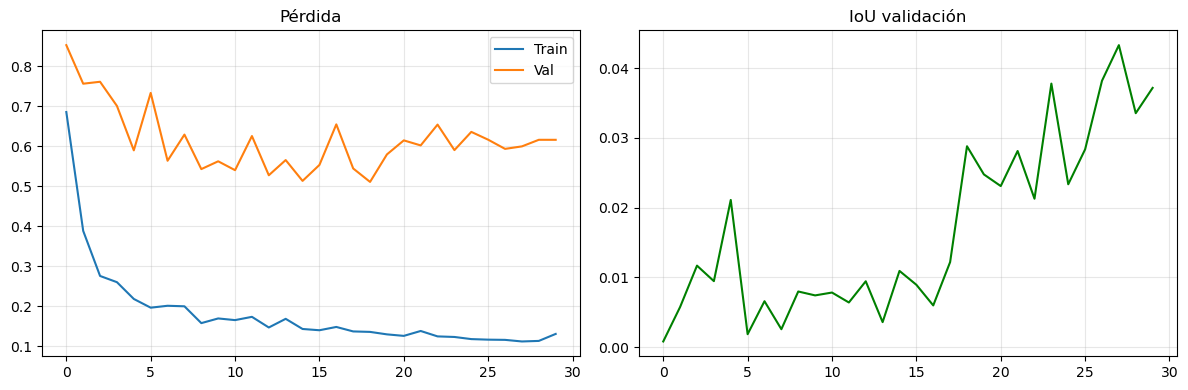

Mejor IoU: 0.0433


In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(historial["train_loss"], label="Train")
ax1.plot(historial["val_loss"],   label="Val")
ax1.set_title("Pérdida"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(historial["val_iou"], color="green")
ax2.set_title("IoU validación"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(MODELO_DESTINO.parent / "curvas_entrenamiento.png"), dpi=150)
plt.show()
print(f"Mejor IoU: {max(historial['val_iou']):.4f}")


## 7. Listo

El modelo está en `backend/ia/modelo_danos.pt`.

Reinicia el backend:
```
cd C:\Users\adria\Documents\mapaid\backend
python -m uvicorn main:app --reload --port 8000
```

El backend lo detecta automáticamente y lo usa en vez del comparador de píxeles.
